# bayesflow_hpo Quickstart

A minimal end-to-end example that shows how to run **hyperparameter optimization** (HPO) for a [BayesFlow 2.x](https://bayesflow.org) amortized inference workflow.

We will:

1. Define a simple Gaussian **simulator** (prior + likelihood).
2. Build a BayesFlow **adapter** that maps raw simulation output to the format expected by the neural network.
3. Launch an Optuna-backed **multi-objective optimization** run that searches over network architectures and training hyperparameters.
4. Inspect results: Pareto front, hyperparameter importance, and metric summaries.

## 0. Setup

Install the package (editable mode from the repo root) and import the two libraries we need:
- **`bayesflow`** — the core amortized Bayesian inference framework (simulators, adapters, workflows),
- **`bayesflow_hpo`** — this package, which adds HPO search spaces, objectives, and validation utilities on top.

In [1]:
%pip install --quiet --upgrade -e ..

import bayesflow as bf
import bayesflow_hpo as hpo
import numpy as np

Note: you may need to restart the kernel to use updated packages.


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Simulator & Adapter

**Simulator** — We define a toy generative model with a 1-D Gaussian prior $\theta \sim \mathcal{N}(0, 1)$ and a Gaussian likelihood $x_i \mid \theta \sim \mathcal{N}(\theta, 1)$ producing 12 observations per dataset. This is deliberately simple so the notebook runs in seconds.

**Adapter** — The `bf.Adapter` tells BayesFlow how to reshape the raw simulation dictionaries into the tensor format the neural network expects:
- `.as_set(["x"])` marks observation vectors as exchangeable (order doesn't matter),
- `.rename("theta", "inference_variables")` maps the parameter to the inference target,
- `.concatenate(["x"], into="summary_variables")` stacks observations into the summary input.

`optimize()` automatically infers `param_keys` and `data_keys` from the adapter's `Rename`/`Concatenate` transforms, and generates a fixed validation dataset internally — so we only need the simulator and adapter.

In [2]:
def prior_fn():
    return {"theta": np.random.normal(0.0, 1.0, size=(1,)).astype("float32")}


def likelihood_fn(theta):
    theta_value = float(np.squeeze(theta))
    x = np.random.normal(theta_value, 1.0, size=(12, 1)).astype("float32")
    return {"x": x}


simulator = bf.simulators.make_simulator([prior_fn, likelihood_fn])
adapter = (
    bf.Adapter()
    .as_set(["x"])
    .rename("theta", "inference_variables")
    .concatenate(["x"], into="summary_variables", axis=-1)
)

## 2. Run HPO

`hpo.optimize` is the main entry point. Under the hood it:

1. **Infers keys** from the adapter — `param_keys=["theta"]` and `data_keys=["x"]` are detected automatically from the `Rename`/`Concatenate` transforms.
2. **Generates a fixed validation dataset** — drawn once from the simulator and reused across all trials for fair comparison.
3. **Creates an Optuna study** with three objectives (in `"pareto"` mode): *calibration_error* (minimize), *nrmse* (minimize), and *inference_time* (minimize) — a Pareto-style trade-off between accuracy metrics and computational cost.
4. **Samples hyperparameters** from a `CompositeSearchSpace` that covers the inference network (flow matching), the summary network (DeepSet), and training settings (learning rate).
5. **Builds, trains, and validates** a fresh `bf.BasicWorkflow` for each trial, using SBC-based metrics on the fixed validation dataset.
6. **Reports results** back to Optuna, which guides future sampling via its TPE (Tree-structured Parzen Estimator) sampler.

Key arguments in this example:
| Argument | Value | Why |
|---|---|---|
| `n_trials` | 5 | Number of HPO configurations to try (increase for real use) |
| `epochs` | 30 | Enough gradient steps for meaningful metric signal |
| `batches_per_epoch` | 30 | 900 gradient steps per trial — fast demo |
| `max_param_count` | 500,000 | Reject very large models before training |
| `objective_metrics` | `["calibration_error", "nrmse"]` | Combines coverage quality with point-estimate accuracy |
| `objective_mode` | `"pareto"` | Each metric becomes a separate Pareto objective (plus the cost metric) |
| `train_fn` | compatibility hook | Maps `batches_per_epoch` to `num_batches` for BayesFlow versions that require it |
| `storage` | `None` | In-memory study — no leftover database files |

After optimization, `study.best_trials` returns the Pareto-optimal trial(s).

In [4]:
import bayesflow_hpo as hpo

# Use a focused search space for the demo (flow matching + deep set).
search_space = hpo.CompositeSearchSpace(
    inference_space=hpo.FlowMatchingSpace(),
    summary_space=hpo.DeepSetSpace(),
    training_space=hpo.TrainingSpace(),
)

# BayesFlow 2.0.8 expects `num_batches` in fit(); map from HPO's `batches_per_epoch`.
def train_fn(approximator, simulator, hparams, callbacks):
    approximator.fit(
        simulator=simulator,
        epochs=int(hparams["epochs"]),
        batch_size=int(hparams.get("batch_size", 256)),
        num_batches=int(hparams["batches_per_epoch"]),
        callbacks=callbacks,
    )

study = hpo.optimize(
    # Model
    simulator=simulator,
    adapter=adapter,
    # Search
    search_space=search_space,
    n_trials=5,
    epochs=30,
    batches_per_epoch=30,
    max_param_count=500_000,
    # Objectives
    objective_metrics=["calibration_error", "nrmse"],
    objective_mode="pareto",
    # Use compatibility train hook for current BayesFlow fit() kwargs
    train_fn=train_fn,
    # In-memory study (no leftover .db files)
    storage=None,
    show_progress_bar=False,
)

print(f"Trials: {len(study.trials)}")
print(f"Pareto-optimal trials: {len(study.best_trials)}")
if study.best_trials:
    best = min(
        study.best_trials,
        key=lambda t: t.user_attrs.get("calibration_error", float("inf")),
    )
    itr = best.user_attrs.get("inference_time_ratio", float("nan"))
    print(
        f"Best trial by calibration_error: "
        f"{best.user_attrs.get('calibration_error', float('nan')):.4f} "
        f"(nrmse={best.user_attrs.get('nrmse', float('nan')):.4f}, "
        f"inference_time_ratio={itr:.4f})"
    )

INFO:bayesflow:Building dataset from simulator instance of SequentialSimulator.
INFO:bayesflow:Using 16 data loading workers.
INFO:bayesflow:Building on a test batch.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 3.0868


Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.94s/batch]
c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-03-15 12:56:41,352] A new study created in memory with name: bayesflow_hpo
INFO:bayesflow:Building dataset from simulator instance of SequentialSimulator.
INFO:bayesflow:Using 16 data loading workers.


Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 1.6762 - moving_avg_loss: 1.6762
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.7949 - moving_avg_loss: 1.2355
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - loss: 0.6578 - moving_avg_loss: 1.0430
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - loss: 0.5743 - moving_avg_loss: 0.9258
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - loss: 0.6036 - moving_avg_loss: 0.8614
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.5896 - moving_avg_loss: 0.8161
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.5477 - moving_avg_loss: 0.7777
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.5214 - moving_avg_loss: 0.6128
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.5228 - moving_avg_loss: 0.5739
Epoch 10/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.5252 - moving_avg_loss: 0.5550
Epoch 11/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.5023

Sampling: 100%|██████████| 1/1 [01:15<00:00, 75.05s/batch]


...

30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - loss: 0.7077 - moving_avg_loss: 0.8479
Epoch 12/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.6909 - moving_avg_loss: 0.7931
Epoch 13/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.6771 - moving_avg_loss: 0.7510
Epoch 14/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - loss: 0.6993 - moving_avg_loss: 0.7324
Epoch 15/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - loss: 0.6818 - moving_avg_loss: 0.7102
Epoch 16/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - loss: 0.6449 - moving_avg_loss: 0.6899
Epoch 17/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - loss: 0.6472 - moving_avg_loss: 0.6784
Epoch 18/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - loss: 0.6116 - moving_avg_loss: 0.6647
Epoch 19/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.6060 - moving_avg_loss: 0.6526
Epoch 20/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - loss: 0.6169 - moving_avg_loss: 0.6440
Epoch 21/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.6030

Sampling: 100%|██████████| 1/1 [00:35<00:00, 35.26s/batch]


30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.6030 - moving_avg_loss: 0.6302
Epoch 22/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.5956 - moving_avg_loss: 0.6179
Epoch 23/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.6128 - moving_avg_loss: 0.6133
Epoch 24/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - loss: 0.5805 - moving_avg_loss: 0.6038
Epoch 25/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - loss: 0.6109 - moving_avg_loss: 0.6037
Epoch 26/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.5978 - moving_avg_loss: 0.6025
Epoch 27/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - loss: 0.6093 - moving_avg_loss: 0.6014
Epoch 28/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.6075 - moving_avg_loss: 0.6020
Epoch 29/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.6141 - moving_avg_loss: 0.6047
Epoch 30/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - loss: 0.6435 - moving_avg_loss: 0.6091


Sampling: 100%|██████████| 1/1 [01:11<00:00, 71.19s/batch]
INFO:bayesflow_hpo.optimization.objective:Trial #4 done (218s) | calibration_error: 0.0251 | params: 49.5K | nrmse: 0.0545 | corr: 0.9603
[I 2026-03-15 13:37:06,460] Trial 4 finished with values: [0.02513157894736845, 0.054545139626952066, 3134.709632594031] and parameters: {'fm_subnet_width': 32, 'fm_subnet_depth': 4, 'fm_dropout': 0.19312640661491187, 'ds_summary_dim': 53, 'ds_depth': 2, 'ds_width': 32, 'ds_dropout': 0.20526990795364705, 'initial_lr': 0.0005595074635794797}.
INFO:bayesflow_hpo.optimization.study:Progress: 5/5 trained | 5 total | best: 0.0089


Trials: 5
Pareto-optimal trials: 4
Best trial by calibration_error: 0.0089 (nrmse=0.0498, inference_time_ratio=8906.6219)


## 3. Inspect Results

### 3.1 Pareto Front

The optimization minimizes *three* objectives simultaneously (in `"pareto"` mode):
- **calibration_error** — lower = better-calibrated posterior approximation,
- **nrmse** — lower = more accurate point estimates,
- **inference_time_ratio** — lower = faster inference relative to simulation.

These objectives trade off against each other: a very large network may achieve low calibration error but is expensive to run. The **Pareto front** (projected onto calibration error vs. parameter count) shows the set of trials that are not dominated — no other trial is simultaneously cheaper *and* better calibrated.

### 3.2 Hyperparameter Importance

After all trials have run, Optuna's **fANOVA-based importance estimator** assigns each hyperparameter a score reflecting how much its variation explains the variance in the first objective (calibration error). High-importance hyperparameters are worth tuning carefully in follow-up studies.

### 3.3 Optimization History

The convergence plot shows how the best first-objective value evolves over successive trials. A healthy HPO run should trend downward — if it plateaus early, more trials won't help and you should widen the search space instead.

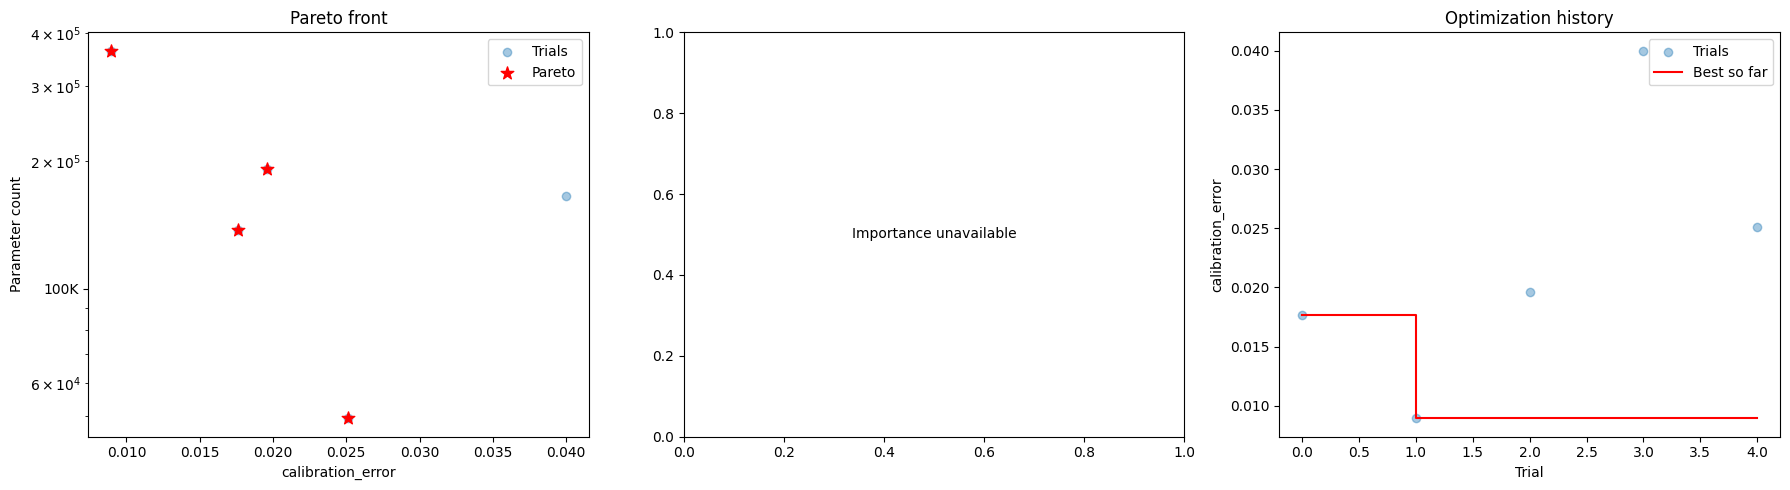

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3.1 Pareto front: calibration error vs parameter count
hpo.plot_pareto_front(study, ax=axes[0])

# 3.2 Hyperparameter importance (fANOVA)
hpo.plot_param_importance(study, ax=axes[1])

# 3.3 Optimization history (first objective over trials)
hpo.plot_optimization_history(study, ax=axes[2])

plt.tight_layout()
plt.show()

### 3.4 Metric Scatter

`plot_metric_scatter` shows two per-trial metrics against each other, colored by their mean value.
Points on the 2D Pareto front (neither metric dominated) are highlighted in red.
This helps spot whether calibration error and NRMSE are correlated or reveal distinct trade-offs.

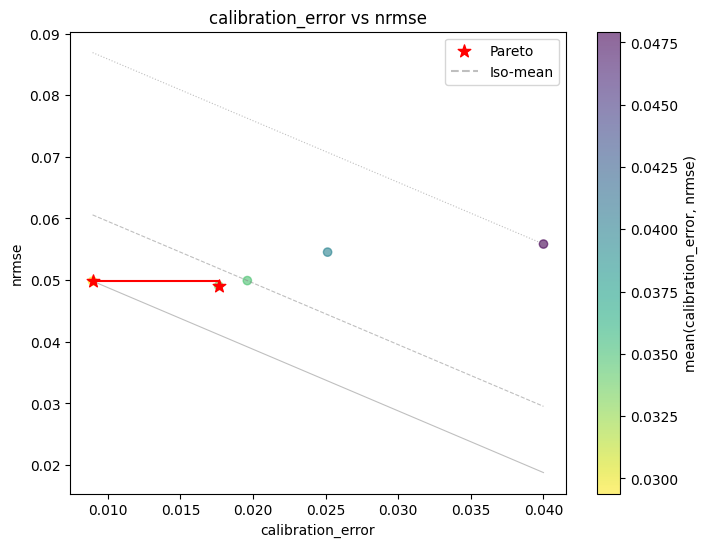

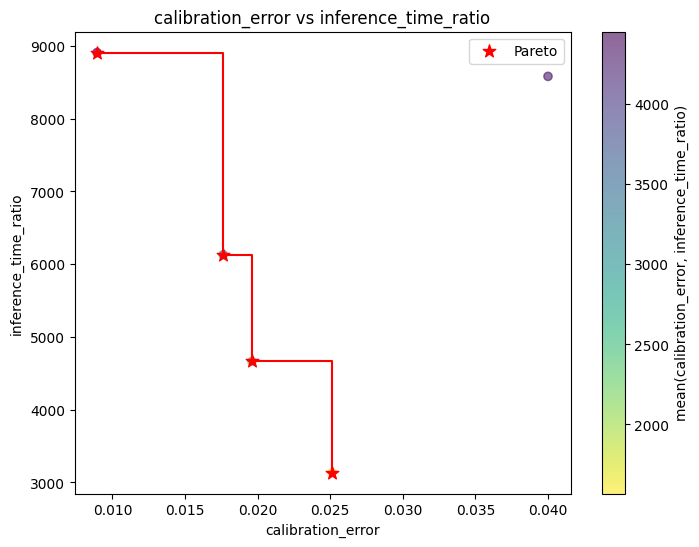

In [6]:
hpo.plot_metric_scatter(study, "calibration_error", "nrmse", show_iso_lines=True)
hpo.plot_metric_scatter(study, "calibration_error", "inference_time_ratio")

plt.show()

### 3.5 Tabular Summary

`trials_to_dataframe` converts completed trials into a `pandas.DataFrame` with one row per trial and columns for every hyperparameter, objective values, and validation metrics (NRMSE, correlation, coverage, etc.). Budget-rejected trials are excluded by default.

The table is sorted by calibration error (the first objective) so the best architectures appear at the top.

In [7]:
df = hpo.trials_to_dataframe(study)
print(f"Completed trials: {len(df)}")

# Show the most informative columns, sorted by calibration error
key_cols = ["trial_number", "calibration_error", "nrmse", "inference_time_ratio",
            "param_count", "correlation", "coverage_90", "coverage_95", "training_time_s"]
display_cols = [c for c in key_cols if c in df.columns]
df.sort_values("calibration_error")[display_cols]

Completed trials: 5


,trial_number,calibration_error,nrmse,inference_time_ratio,param_count,correlation,coverage_90,coverage_95,training_time_s
1,1,0.008947,0.049842,8906.621889,363954,0.961360,0.910,0.970,476.91
0,0,0.017632,0.049087,6129.157618,137583,0.962192,0.880,0.925,283.39
2,2,0.019605,0.049928,4665.139693,191285,0.961657,0.900,0.955,331.90
4,4,0.025132,0.054545,3134.709633,49490,0.960289,0.870,0.930,218.42
3,3,0.040000,0.055856,8579.807727,165031,0.957657,0.925,0.970,393.59


### 3.6 Study Summary

`summarize_study` prints a concise overview: trial counts (trained, rejected, pruned, failed), the Pareto front, the best trial by calibration error, a top-k leaderboard, and the winning hyperparameters — everything you need to decide which configuration to use for downstream inference.

In [8]:

print(hpo.summarize_study(study, top_k=5))

Study: bayesflow_hpo
Trials: 5 total | 5 trained | 0 budget-rejected | 0 pruned | 0 failed
Objectives: calibration_error, nrmse, inference_time

Pareto front: 4 trials
------------------------------------------------------------
Best by calibration_error:
  Trial #1
    calibration_error        : 0.0089
    nrmse                    : 0.0498
    inference_time           : 8906.6219
    Param count              : 364.0K
    Training time (s)        : 476.9100
    Inference time (s)       : 203.0600
    Inference/sim ratio      : 8906.6219
    NRMSE                    : 0.0498
    Correlation              : 0.9614
    Contraction              : 0.9192
    Coverage 90%             : 0.9100
    Coverage 95%             : 0.9700

Top 5 trials (by calibration_error):
------------------------------------------------------------
  #   1  |  calibration_error: 0.0089  |  nrmse: 0.0498  |  inference_time: 8906.6219  |  params: 364.0K  |  corr: 0.9614
  #   0  |  calibration_error: 0.0176  |  nrms